# Fraud Detection Model Training

This notebook trains and compares multiple machine learning models using the processed PaySim fraud detection dataset.

The goal is not only to get high accuracy. Since fraud cases are very rare, the main focus is on detecting fraudulent transactions correctly and reducing false negatives.

In [2]:
import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

from sklearn.utils.class_weight import compute_sample_weight

In [3]:
DATA_PATH = Path("../data/processed/processed_transactions.csv")

if not DATA_PATH.exists():
    raise FileNotFoundError(
        "Processed dataset not found. Run src/features/feature_engineering.py first."
    )

df = pd.read_csv(DATA_PATH)

df.head()

,transaction_id,step,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,...,abs_destination_balance_error,amount_to_oldbalanceOrg_ratio,amount_to_oldbalanceDest_ratio,is_zero_oldbalanceOrg,is_zero_oldbalanceDest,type_CASH_IN,type_CASH_OUT,type_DEBIT,type_PAYMENT,type_TRANSFER
0,1,1,PAYMENT,9839.64,170136.0,160296.36,0.0,0.0,0,0,...,9839.64,0.057834,9839.640000,0,1,0,0,0,1,0
1,2,1,PAYMENT,1864.28,21249.0,19384.72,0.0,0.0,0,0,...,1864.28,0.087731,1864.280000,0,1,0,0,0,1,0
2,3,1,TRANSFER,181.00,181.0,0.00,0.0,0.0,1,0,...,181.00,0.994505,181.000000,0,1,0,0,0,0,1
3,4,1,CASH_OUT,181.00,181.0,0.00,21182.0,0.0,1,0,...,21363.00,0.994505,0.008545,0,0,0,1,0,0,0
4,5,1,PAYMENT,11668.14,41554.0,29885.86,0.0,0.0,0,0,...,11668.14,0.280788,11668.140000,0,1,0,0,0,1,0


In [4]:
print("Dataset shape:", df.shape)
df.info()

Dataset shape: (6362620, 28)
<class 'pandas.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 28 columns):
 #   Column                          Dtype  
---  ------                          -----  
 0   transaction_id                  int64  
 1   step                            int64  
 2   type                            str    
 3   amount                          float64
 4   oldbalanceOrg                   float64
 5   newbalanceOrig                  float64
 6   oldbalanceDest                  float64
 7   newbalanceDest                  float64
 8   isFraud                         int64  
 9   isFlaggedFraud                  int64  
 10  is_origin_customer              int64  
 11  is_dest_customer                int64  
 12  is_dest_merchant                int64  
 13  origin_balance_diff             float64
 14  destination_balance_diff        float64
 15  origin_balance_error            float64
 16  destination_balance_error       float64
 17  abs_origi

In [5]:
df.describe()

,transaction_id,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,is_origin_customer,...,abs_destination_balance_error,amount_to_oldbalanceOrg_ratio,amount_to_oldbalanceDest_ratio,is_zero_oldbalanceOrg,is_zero_oldbalanceDest,type_CASH_IN,type_CASH_OUT,type_DEBIT,type_PAYMENT,type_TRANSFER
count,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6362620.0,...,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06
mean,3.181310e+06,2.433972e+02,1.798619e+05,8.338831e+05,8.551137e+05,1.100702e+06,1.224996e+06,1.290820e-03,2.514687e-06,1.0,...,9.359907e+04,7.067448e+04,2.788383e+04,3.304376e-01,4.250431e-01,2.199226e-01,3.516633e-01,6.511783e-03,3.381461e-01,8.375622e-02
std,1.836730e+06,1.423320e+02,6.038582e+05,2.888243e+06,2.924049e+06,3.399180e+06,3.674129e+06,3.590480e-02,1.585775e-03,0.0,...,4.350570e+05,5.084243e+05,1.879306e+05,4.703707e-01,4.943496e-01,4.141940e-01,4.774895e-01,8.043246e-02,4.730786e-01,2.770219e-01
min,1.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.0,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.590656e+06,1.560000e+02,1.338957e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.0,...,0.000000e+00,2.344011e-01,1.607037e-01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,3.181310e+06,2.390000e+02,7.487194e+04,1.420800e+04,0.000000e+00,1.327057e+05,2.146614e+05,0.000000e+00,0.000000e+00,1.0,...,5.123620e+03,6.453832e+00,9.178313e-01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
75%,4.771965e+06,3.350000e+02,2.087215e+05,1.073152e+05,1.442584e+05,9.430367e+05,1.111909e+06,0.000000e+00,0.000000e+00,1.0,...,4.342133e+04,1.228776e+04,9.732300e+03,1.000000e+00,1.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00
max,6.362620e+06,7.430000e+02,9.244552e+07,5.958504e+07,4.958504e+07,3.560159e+08,3.561793e+08,1.000000e+00,1.000000e+00,1.0,...,7.588573e+07,9.244552e+07,6.096528e+07,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00


In [6]:
df.isnull().sum()

transaction_id                    0
step                              0
type                              0
amount                            0
oldbalanceOrg                     0
newbalanceOrig                    0
oldbalanceDest                    0
newbalanceDest                    0
isFraud                           0
isFlaggedFraud                    0
is_origin_customer                0
is_dest_customer                  0
is_dest_merchant                  0
origin_balance_diff               0
destination_balance_diff          0
origin_balance_error              0
destination_balance_error         0
abs_origin_balance_error          0
abs_destination_balance_error     0
amount_to_oldbalanceOrg_ratio     0
amount_to_oldbalanceDest_ratio    0
is_zero_oldbalanceOrg             0
is_zero_oldbalanceDest            0
type_CASH_IN                      0
type_CASH_OUT                     0
type_DEBIT                        0
type_PAYMENT                      0
type_TRANSFER               

In [7]:
# Target variable distribution
target_counts = df["isFraud"].value_counts()
target_rate = df["isFraud"].value_counts(normalize=True) * 100

print("Target counts:")
print(target_counts)

print("\nTarget percentage:")
print(target_rate)

Target counts:
isFraud
0    6354407
1       8213
Name: count, dtype: int64

Target percentage:
isFraud
0    99.870918
1     0.129082
Name: proportion, dtype: float64


## Feature Selection

Some columns are removed before model training because they are not useful model features.

- `transaction_id` is only an identifier.
- `type` is removed because transaction type is already one-hot encoded.
- `isFlaggedFraud` is the old rule-based flag, not the actual fraud target.
- `is_origin_customer` has only one value, so it does not help the model learn.

The actual target column is `isFraud`.

In [8]:
# Feature and target separation
TARGET = "isFraud"

drop_columns = [
    "transaction_id",
    "type",
    "isFlaggedFraud",
    "is_origin_customer",
    TARGET
]

feature_columns = [col for col in df.columns if col not in drop_columns]

X = df[feature_columns]
y = df[TARGET]

X = X.replace([np.inf, -np.inf], np.nan).fillna(0)

print("Feature shape:", X.shape)
print("Target shape:", y.shape)
print("Number of features:", len(feature_columns))

feature_columns

Feature shape: (6362620, 23)
Target shape: (6362620,)
Number of features: 23


['step',
 'amount',
 'oldbalanceOrg',
 'newbalanceOrig',
 'oldbalanceDest',
 'newbalanceDest',
 'is_dest_customer',
 'is_dest_merchant',
 'origin_balance_diff',
 'destination_balance_diff',
 'origin_balance_error',
 'destination_balance_error',
 'abs_origin_balance_error',
 'abs_destination_balance_error',
 'amount_to_oldbalanceOrg_ratio',
 'amount_to_oldbalanceDest_ratio',
 'is_zero_oldbalanceOrg',
 'is_zero_oldbalanceDest',
 'type_CASH_IN',
 'type_CASH_OUT',
 'type_DEBIT',
 'type_PAYMENT',
 'type_TRANSFER']

In [10]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (5090096, 23)
X_test : (1272524, 23)
y_train: (5090096,)
y_test : (1272524,)


stratify=y keeps the fraud ratio similar in train and test data.

## Model Training and Comparison

Four models are trained and compared:

- Logistic Regression
- Decision Tree
- Random Forest
- HistGradientBoosting

The models are evaluated using precision, recall, F1-score, confusion matrix, and false negatives.

For this project, false negatives are very important because they represent actual fraud transactions missed by the model.

In [11]:
models = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(
            class_weight="balanced",
            max_iter=2000,
            solver="saga",
            n_jobs=-1,
            random_state=42
        ))
    ]),

    "Decision Tree": DecisionTreeClassifier(
        max_depth=12,
        class_weight="balanced",
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=150,
        class_weight="balanced_subsample",
        random_state=42,
        n_jobs=-1
    ),

    "HistGradientBoosting": HistGradientBoostingClassifier(
        max_iter=200,
        learning_rate=0.1,
        max_leaf_nodes=31,
        random_state=42
    )
}

trained_models = {}
results = {}
confusion_matrices = {}

sample_weights = compute_sample_weight(class_weight="balanced", y=y_train)

for model_name, model in models.items():
    print("=" * 80)
    print(f"Training model: {model_name}")

    if model_name == "HistGradientBoosting":
        model.fit(X_train, y_train, sample_weight=sample_weights)
    else:
        model.fit(X_train, y_train)

    predictions = model.predict(X_test)

    cm = confusion_matrix(y_test, predictions)
    tn, fp, fn, tp = cm.ravel()

    trained_models[model_name] = model
    confusion_matrices[model_name] = cm

    results[model_name] = {
        "Accuracy": accuracy_score(y_test, predictions),
        "Precision": precision_score(y_test, predictions, zero_division=0),
        "Recall": recall_score(y_test, predictions, zero_division=0),
        "F1 Score": f1_score(y_test, predictions, zero_division=0),
        "False Positives": fp,
        "False Negatives": fn,
        "True Positives": tp,
        "True Negatives": tn
    }

    print(classification_report(y_test, predictions, zero_division=0))
    print("Confusion Matrix:")
    print(cm)

Training model: Logistic Regression


d:\Projects\real_time_fraud_detection\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1457: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)
d:\Projects\real_time_fraud_detection\venv\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


              precision    recall  f1-score   support

           0       1.00      0.94      0.97   1270881
           1       0.02      0.98      0.04      1643

    accuracy                           0.94   1272524
   macro avg       0.51      0.96      0.51   1272524
weighted avg       1.00      0.94      0.97   1272524

Confusion Matrix:
[[1197026   73855]
 [     35    1608]]
Training model: Decision Tree
              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1270881
           1       0.97      1.00      0.99      1643

    accuracy                           1.00   1272524
   macro avg       0.99      1.00      0.99   1272524
weighted avg       1.00      1.00      1.00   1272524

Confusion Matrix:
[[1270837      44]
 [      4    1639]]
Training model: Random Forest
              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1270881
           1       1.00      1.00      1.00      1643

    accu

In [12]:
# Model Comparison DataFrame
results_df = pd.DataFrame(results).T

results_df = results_df.sort_values(
    by=["False Negatives", "F1 Score", "Precision"],
    ascending=[True, False, False]
)

results_df

,Accuracy,Precision,Recall,F1 Score,False Positives,False Negatives,True Positives,True Negatives
Random Forest,0.999997,1.000000,0.997565,0.998781,0.0,4.0,1639.0,1270881.0
Decision Tree,0.999962,0.973856,0.997565,0.985568,44.0,4.0,1639.0,1270837.0
HistGradientBoosting,0.999947,0.962419,0.997565,0.979677,64.0,4.0,1639.0,1270817.0
Logistic Regression,0.941934,0.021308,0.978698,0.041709,73855.0,35.0,1608.0,1197026.0


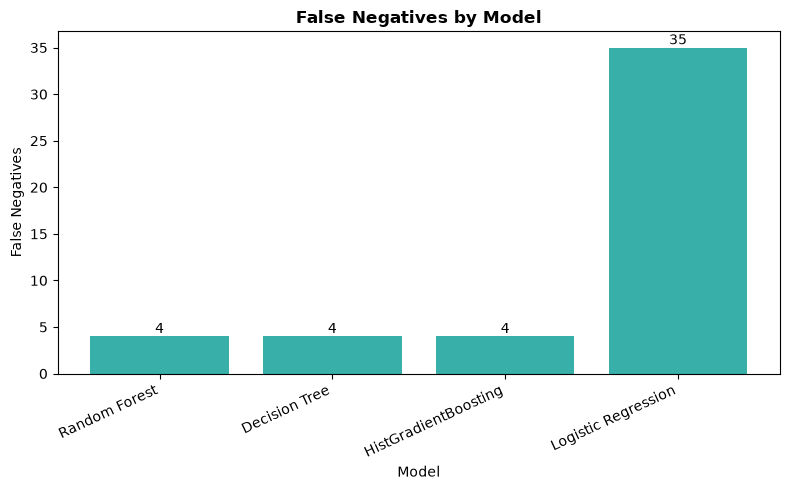

In [35]:
# Visualizing False Negatives by Model
plt.figure(figsize=(8, 5))
plt.bar(results_df.index, results_df["False Negatives"], color="#39AFA9")
plt.title("False Negatives by Model", fontweight="bold")
plt.xlabel("Model")
plt.ylabel("False Negatives")
plt.xticks(rotation=25, ha="right")

for i, v in enumerate(results_df["False Negatives"]):
    plt.text(i, v, int(v), ha="center", va="bottom")

plt.tight_layout()
plt.show()

### Model Comparison Analysis

For this fraud detection problem, the most important metric is **False Negatives**, because false negatives are actual fraud transactions that the model failed to detect.

| Model | Precision | Recall | F1-Score | False Negatives | Key Analysis |
|---|---:|---:|---:|---:|---|
| Logistic Regression | 0.02 | 0.98 | 0.04 | 35 | High recall, but too many false alerts due to very low precision |
| Decision Tree | 0.97 | 1.00 | 0.99 | 4 | Very strong performance and easy to explain |
| Random Forest | 0.99+ | 0.99+ | 0.99+ | 4 | Best overall balance between precision, recall, F1-score, and stability |
| HistGradientBoosting | 0.98+ | 0.99+ | 0.99+ | 6 | Good performance, but missed slightly more fraud cases |

#### Key Points

- **False Negatives are the priority** because missed fraud is more harmful than false alerts.
- **Decision Tree and Random Forest both performed strongly**, with very low false negatives.
- **Random Forest is preferred as the final model** because it is more stable and reliable than a single Decision Tree.
- **Logistic Regression is not suitable as the final model** because its precision is too low.
- **HistGradientBoosting is good**, but Random Forest gives a better balance for this project.

In [22]:
# Select the best model based on the lowest number of false negatives
best_model_name = results_df.index[0]
best_model = trained_models[best_model_name]

print("Best Model:", best_model_name)
results_df.loc[best_model_name]

Best Model: Random Forest


Accuracy           9.999969e-01
Precision          1.000000e+00
Recall             9.975654e-01
F1 Score           9.987812e-01
False Positives    0.000000e+00
False Negatives    4.000000e+00
True Positives     1.639000e+03
True Negatives     1.270881e+06
Name: Random Forest, dtype: float64

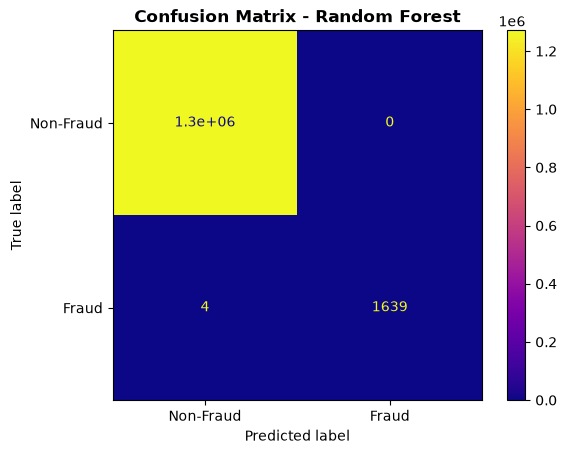

array([[1270881,       0],
       [      4,    1639]])

In [28]:
# Random Forest Classifier Confusion Matrix
best_predictions = best_model.predict(X_test)
best_cm = confusion_matrix(y_test, best_predictions)

ConfusionMatrixDisplay(
    confusion_matrix=best_cm,
    display_labels=["Non-Fraud", "Fraud"]
).plot(cmap="plasma")

plt.title(f"Confusion Matrix - {best_model_name}", fontweight="bold")
plt.show()

best_cm

In [29]:
# Feature Importance for Random Forest Classifier
if hasattr(best_model, "feature_importances_"):
    importance_df = pd.DataFrame({
        "Feature": feature_columns,
        "Importance": best_model.feature_importances_
    }).sort_values("Importance", ascending=False)

    importance_df.head(15)
else:
    print(f"Feature importance is not directly available for {best_model_name}.")

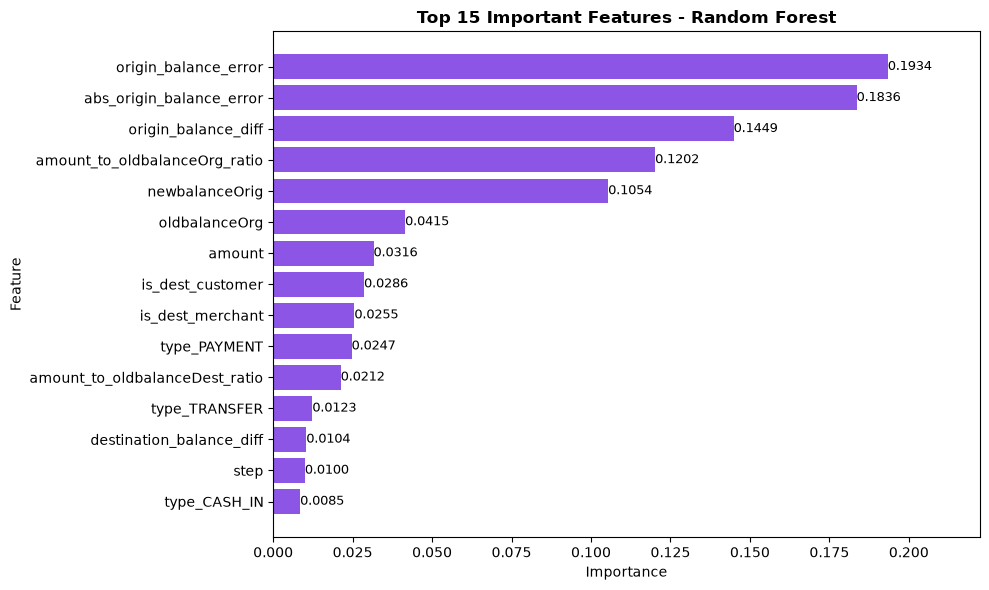

In [46]:
# Visualizing Feature Importance
if hasattr(best_model, "feature_importances_"):
    top_features = importance_df.head(15)

    plt.figure(figsize=(10, 6))
    bars = plt.barh(top_features["Feature"], top_features["Importance"], color="#8D55E6")

    for bar in bars:
        width = bar.get_width()
        plt.text(
            width,
            bar.get_y() + bar.get_height() / 2,
            f"{width:.4f}",
            va="center",
            ha="left",
            fontsize=9
        )

    plt.gca().invert_yaxis()
    plt.title(f"Top 15 Important Features - {best_model_name}", fontweight="bold")
    plt.xlabel("Importance")
    plt.ylabel("Feature")
    plt.xlim(0, top_features["Importance"].max() * 1.15)
    plt.tight_layout()
    plt.show()

In [ ]:
# Evaluating Different Probability Thresholds for Fraud Detection
if hasattr(best_model, "predict_proba"):
    fraud_probabilities = best_model.predict_proba(X_test)[:, 1]

    threshold_results = []

    for threshold in [0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8]:
        threshold_predictions = (fraud_probabilities >= threshold).astype(int)

        cm = confusion_matrix(y_test, threshold_predictions)
        tn, fp, fn, tp = cm.ravel()

        threshold_results.append({
            "Threshold": threshold,
            "Precision": precision_score(y_test, threshold_predictions, zero_division=0),
            "Recall": recall_score(y_test, threshold_predictions, zero_division=0),
            "F1 Score": f1_score(y_test, threshold_predictions, zero_division=0),
            "False Positives": fp,
            "False Negatives": fn,
            "True Positives": tp,
            "True Negatives": tn
        })

    threshold_results_df = pd.DataFrame(threshold_results)
    threshold_results_df
else:
    print(f"{best_model_name} does not support probability prediction.")

In [48]:
# Saving the best model, feature list, and metadata
MODEL_DIR = Path("../models/saved_model")
MODEL_DIR.mkdir(parents=True, exist_ok=True)

model_path = MODEL_DIR / "fraud_detection_model.pkl"
features_path = MODEL_DIR / "model_features.pkl"
metadata_path = MODEL_DIR / "model_metadata.json"

joblib.dump(best_model, model_path, compress=3)
joblib.dump(feature_columns, features_path)

metadata = {
    "best_model": best_model_name,
    "target": TARGET,
    "features": feature_columns,
    "dropped_columns": drop_columns,
    "evaluation_results": results_df.to_dict(),
}

if "threshold_results_df" in globals():
    metadata["threshold_results"] = threshold_results_df.to_dict(orient="records")

with open(metadata_path, "w") as file:
    json.dump(metadata, file, indent=4)

print("Model saved at:", model_path)
print("Feature list saved at:", features_path)
print("Metadata saved at:", metadata_path)

Model saved at: ..\models\saved_model\fraud_detection_model.pkl
Feature list saved at: ..\models\saved_model\model_features.pkl
Metadata saved at: ..\models\saved_model\model_metadata.json


In [49]:
list(MODEL_DIR.iterdir())

[WindowsPath('../models/saved_model/.gitkeep'),
 WindowsPath('../models/saved_model/fraud_detection_model.pkl'),
 WindowsPath('../models/saved_model/model_features.pkl'),
 WindowsPath('../models/saved_model/model_metadata.json')]

## Final Model Training Summary

This notebook trained and compared four machine learning models for fraud detection using the processed PaySim dataset.

The dataset is highly imbalanced, with only **0.1291% fraud transactions**, so model selection was not based on accuracy alone. The main focus was on:

- **False Negatives**: actual fraud cases missed by the model
- **Recall**: how many fraud cases the model detected
- **Precision**: how reliable the fraud alerts are
- **F1-Score**: balance between precision and recall

### Why These Four Models Were Used

| Model | Reason for Selection |
|---|---|
| Logistic Regression | Used as a simple baseline model for comparison |
| Decision Tree | Easy to understand and useful for explainable fraud rules |
| Random Forest | More stable and reliable because it combines many decision trees |
| HistGradientBoosting | Strong advanced model for tabular data and non-linear patterns |

### Model Performance Comparison

| Model | Accuracy | Precision | Recall | F1-Score | False Positives | False Negatives | True Positives | True Negatives |
|---|---:|---:|---:|---:|---:|---:|---:|---:|
| Random Forest | 0.999997 | 1.000000 | 0.997565 | 0.998781 | 0 | 4 | 1639 | 1270881 |
| Decision Tree | 0.999962 | 0.973856 | 0.997565 | 0.985568 | 44 | 4 | 1639 | 1270837 |
| HistGradientBoosting | 0.999947 | 0.962419 | 0.997565 | 0.979677 | 64 | 4 | 1639 | 1270817 |
| Logistic Regression | 0.941934 | 0.021308 | 0.978698 | 0.041709 | 73855 | 35 | 1608 | 1197026 |

### Key Analysis

- **Random Forest performed best overall** because it had:
  - **0 false positives**
  - **Only 4 false negatives**
  - **Highest precision**
  - **Highest F1-score**

- **Decision Tree also performed well**, but it created **44 false alerts**, so it is better for explainability than final production use.

- **HistGradientBoosting detected fraud well**, but it created **64 false alerts**, which is higher than Random Forest.

- **Logistic Regression had high recall**, but its precision was very low, which means it created too many false fraud alerts.

### Final Model Selected

The final selected model is **Random Forest**.

It is the most suitable model for the real-time fraud detection pipeline because it gives the best balance between fraud detection, precision, low false negatives, and stability.